# Quantitative Medical Image Analysis with Python

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter1_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**A hands-on course: from reading your first DICOM file to quantifying body composition on a real CT scan.**

| Chapter | You learn | Why the final analysis needs it |
|---|---|---|
| **1. Exploration** | Load DICOM, read metadata, Hounsfield units, plot N-dimensional volumes | Every measurement starts from correctly loaded, correctly scaled voxels |
| **2. Masks and filters** | Histograms, thresholding, convolution, denoising, edge detection | Fat and muscle are selected by HU thresholds — after denoising |
| **3. Measurement** | Labeling, object selection, area/volume, intensity statistics | Cross-sectional areas and mean HU *are* the body composition metrics |
| **4. Image comparison** | Transformations, resampling, similarity metrics, normalization | Comparing patients requires common geometry and size-normalized indices |
| **5. Body composition from CT** | Muscle / subcutaneous fat / visceral fat quantification at L3 | The destination |
| **6. Body composition from MR** | Dixon water–fat separation, fat-fraction maps | The other modality that can do this, and why CT is still the default |

### About the data

This repository contains **no imaging data**. Every notebook downloads what it needs from the
original public source and caches it under `data/`. That keeps the repository small, keeps the
licensing clean, and — more importantly — means you always know exactly where the numbers you
compute came from. Each loader prints its citation.

This chapter uses an abdominal CT from the **Pancreas-CT** collection at
[The Cancer Imaging Archive](https://www.cancerimagingarchive.net/), fetched through the public
NBIA API. No account is required.

---

# Chapter 1: Exploration

A medical image is a NumPy array plus the context needed to interpret it. This chapter is about
both halves of that sentence.

By the end you will be able to:

1. Download a real CT series and load it into a 3D array.
2. Read acquisition metadata, and explain why it — not the pixel values alone — makes an image measurable.
3. Convert stored values into **Hounsfield units**, the calibrated scale that makes CT quantitative.
4. Convert an image into a PyTorch tensor for downstream deep-learning work.
5. Plot volumes by slicing them, in any of the three anatomical planes, with correct aspect ratios.

## Setup

Run this cell first. On Colab it clones the repository and installs the packages the runtime is
missing; locally it just moves to the repository root.

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", os.getcwd())

Running on Colab: False
Working directory: /home/wxc151/projects/Biomedical-Image-Analysis-in-Python


## 1. Getting the data

`medimage_data` wraps the download and caching. The first call transfers about 40 MB and takes
roughly 20 seconds; afterwards it reads from the local cache.

In [2]:
import medimage_data as md

ct_dir = md.fetch_pancreas_ct(0)

PANCREAS_0076: 210 slices in data/pancreas-ct/PANCREAS_0076
Source: Roth H, Farag A, Turkbey EB, Lu L, Liu J, Summers RM (2016). Data From Pancreas-CT. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU  (CC BY 3.0)


## 2. Loading one slice

DICOM is the standard format for clinical imaging. A DICOM file is not just a picture: it is a
pixel array bundled with several hundred tags describing the patient, the scanner and the geometry.

**`pydicom`** is the reference DICOM library for Python and the one we use throughout. (You will
also see `imageio` used for medical images; note that only its older `v2` API reads DICOM, and
`imageio.v3` cannot open a DICOM directory at all — so `pydicom` is the safer default.)

In [3]:
import pydicom

paths = sorted(ct_dir.glob("*.dcm"))
ds = pydicom.dcmread(paths[len(paths) // 2])

print("Files in series:", len(paths))
print("Array shape:    ", ds.pixel_array.shape)
print("Stored dtype:   ", ds.pixel_array.dtype)
print("Stored range:   ", ds.pixel_array.min(), "to", ds.pixel_array.max())

Files in series: 210
Array shape:     (512, 512)
Stored dtype:    int16
Stored range:    -1024 to 1201


### The header is the measurement instrument

Everything that turns pixels into physical quantities lives in the header: how big a pixel is, how
far apart the slices are, and how stored values map onto a calibrated scale.

In [4]:
for tag in ["Modality", "BodyPartExamined", "PixelSpacing", "SliceThickness",
            "RescaleSlope", "RescaleIntercept", "WindowCenter", "WindowWidth",
            "PatientID", "PatientSex", "PatientAge", "InstitutionName"]:
    print(f"{tag:20s} {getattr(ds, tag, '<absent>')}")

Modality             CT
BodyPartExamined     PANCREAS
PixelSpacing         [0.8984375, 0.8984375]
SliceThickness       None
RescaleSlope         1
RescaleIntercept     0
WindowCenter         <absent>
WindowWidth          <absent>
PatientID            PANCREAS_0076
PatientSex           
PatientAge           <absent>
InstitutionName      NIH


Two things to notice.

**Some tags are absent or empty.** `PatientAge` and `PatientSex` are blank because TCIA
de-identifies its collections before release. Real analysis code has to tolerate missing tags —
which is why the loader below uses `getattr(d, "RescaleSlope", 1)` rather than `d.RescaleSlope`.

**`SliceThickness` is not the same as slice spacing.** Thickness is how much tissue contributed to
one slice; spacing is the distance between consecutive slice centres. They are often equal, but not
always, and overlapping slices are common. The reliable way to get spacing is to difference the
`ImagePositionPatient` values, which is exactly what `load_series` does below.

### Hounsfield units: why CT can measure tissue

The integers stored in a CT file are on an arbitrary offset scale. The header tells you how to undo
it:

$$\text{HU} = \text{stored value} \times \text{RescaleSlope} + \text{RescaleIntercept}$$

Hounsfield units are *calibrated by definition*: water is 0 HU and air is −1000 HU. That
calibration is the whole reason a fixed threshold such as "fat is −190 to −30 HU" transfers between
scanners, hospitals and studies — and it is what Chapter 5 depends on.

**Skipping this rescale is the most common beginner error in CT analysis.** The image still looks
plausible and every number computed from it is wrong.

In [5]:
import numpy as np

raw = ds.pixel_array
hu = raw * float(getattr(ds, "RescaleSlope", 1)) + float(getattr(ds, "RescaleIntercept", 0))

print("Stored: ", raw.min(), "to", raw.max())
print("HU:     ", hu.min(), "to", hu.max())
print()
print("A voxel of air should read about -1000 HU:", round(float(hu[5, 5]), 1))

Stored:  -1024 to 1201
HU:      -1024.0 to 1201.0

A voxel of air should read about -1000 HU: -1024.0


These are the ranges the rest of the course leans on:

| Tissue | Hounsfield units |
|---|---|
| Air | about −1000 |
| Lung parenchyma | −1000 to −500 |
| **Adipose tissue (fat)** | **−190 to −30** |
| Water | 0 |
| **Skeletal muscle** | **−29 to +150** |
| Bone | +300 and above |

The fat and muscle rows are exactly the windows Chapter 5 uses to segment body compartments.

In [6]:
TISSUE = {
    "air":    (-1024, -600),
    "lung":   (-600, -400),
    "fat":    (-190, -30),
    "muscle": (-29, 150),
    "bone":   (150, 3000),
}

for name, (lo, hi) in TISSUE.items():
    frac = np.count_nonzero((hu >= lo) & (hu < hi)) / hu.size
    print(f"{name:8s} [{lo:5d}, {hi:5d}) HU   {frac:6.1%} of the slice")

air      [-1024,  -600) HU    65.0% of the slice
lung     [ -600,  -400) HU     0.7% of the slice
fat      [ -190,   -30) HU    12.2% of the slice
muscle   [  -29,   150) HU    18.1% of the slice
bone     [  150,  3000) HU     3.0% of the slice


The "air" fraction is large because most of the frame is the space around the patient, not the
patient. Chapter 3 deals with that by finding the body outline first — measuring anything without
excluding the background is another way to get confidently wrong numbers.

## 3. Plotting, and why windowing matters

CT spans roughly 4000 HU, while a screen shows 256 grey levels and the eye resolves fewer. Display
the full range and all soft tissue collapses into indistinguishable greys. Radiologists therefore
view a *window*: a narrow HU interval stretched across the display range.

`imshow(..., vmin=..., vmax=...)` is exactly that. The window changes nothing about the data — only
what you can see.

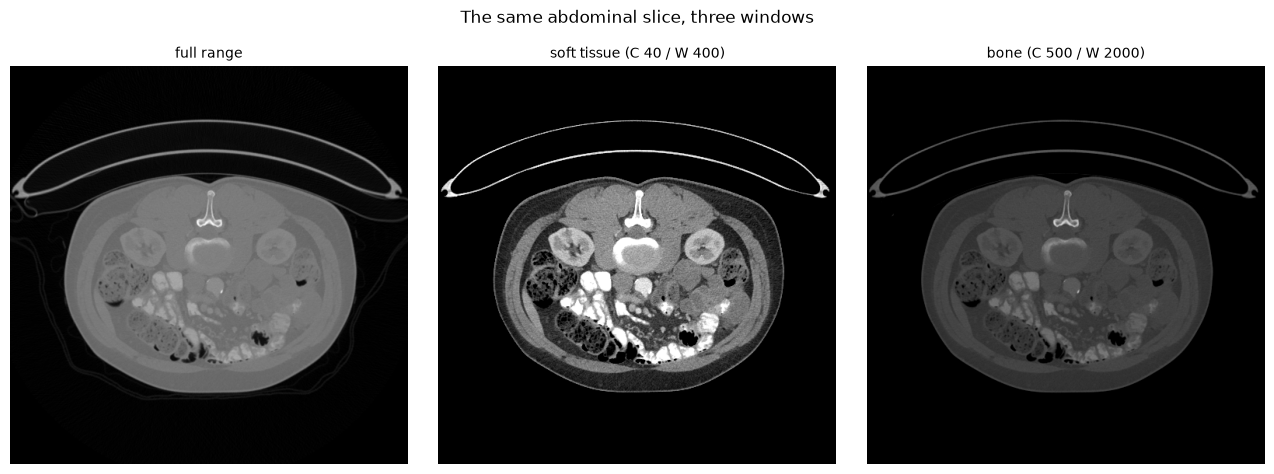

In [7]:
import matplotlib.pyplot as plt


def window(center, width):
    return center - width / 2, center + width / 2


windows = {
    "full range": (hu.min(), hu.max()),
    "soft tissue (C 40 / W 400)": window(40, 400),
    "bone (C 500 / W 2000)": window(500, 2000),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, (title, (vmin, vmax)) in zip(axes, windows.items()):
    ax.imshow(hu, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
fig.suptitle("The same abdominal slice, three windows", y=1.02)
plt.tight_layout()
plt.show()

## 4. From NumPy to PyTorch

Everything downstream of this course — segmentation networks, classifiers, the nnU-Net that
Chapter 5 calls — consumes tensors, not DICOM files. The bridge is short, but three conventions
trip people up:

1. **Layout.** PyTorch expects `(batch, channel, height, width)`; a CT slice is bare `(H, W)`.
2. **Dtype.** Networks want `float32`; DICOM gives `int16` or `uint16`.
3. **Scaling.** Raw HU (−1000 to +3000) is poorly conditioned. Clip to the window you care about,
   then map to roughly `[0, 1]`.

Note that we normalise with *fixed* HU bounds rather than each image's own min and max. Because HU
is calibrated, fixed bounds give every scan the same meaning; per-image normalisation would destroy
exactly the property that makes CT quantitative.

In [8]:
import torch


def ct_to_tensor(hu_array, center=40.0, width=400.0):
    """Window a Hounsfield array and return a (1, 1, H, W) float32 tensor."""
    lo, hi = center - width / 2, center + width / 2
    normalised = (np.clip(hu_array, lo, hi) - lo) / (hi - lo)
    return torch.from_numpy(normalised.astype(np.float32))[None, None]


x = ct_to_tensor(hu)

print("torch version:", torch.__version__)
print("tensor shape: ", tuple(x.shape))
print("dtype:        ", x.dtype)
print("value range:  ", round(float(x.min()), 3), "to", round(float(x.max()), 3))

torch version: 2.13.0+cu130
tensor shape:  (1, 1, 512, 512)
dtype:         torch.float32
value range:   0.0 to 1.0


## 5. N-dimensional images

A 2D image is a stack of rows. A 3D volume is a stack of 2D images. A 4D time series is a stack of
volumes. The convention is that the *new* axis goes first, so a volume is indexed
`vol[plane, row, column]`.

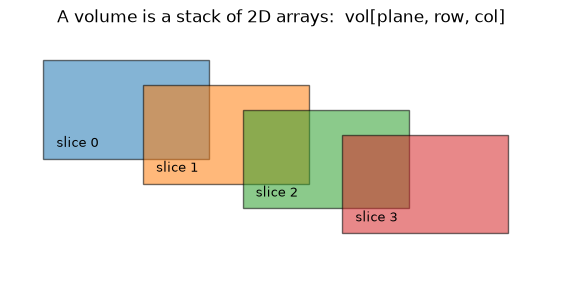

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for i, offset in enumerate([0, 0.9, 1.8, 2.7]):
    ax.add_patch(plt.Rectangle((offset, -offset * 0.28), 1.5, 1.0,
                               facecolor=f"C{i}", alpha=0.55, edgecolor="black"))
    ax.text(offset + 0.12, -offset * 0.28 + 0.12, f"slice {i}", fontsize=9)
ax.set_xlim(-0.3, 4.6)
ax.set_ylim(-1.2, 1.3)
ax.set_title("A volume is a stack of 2D arrays:  vol[plane, row, col]")
ax.axis("off")
plt.show()

### Loading a whole series

Stacking by hand is fine for three files and a bad idea for two hundred — and it is easy to get the
*order* wrong, which silently distorts the anatomy. `load_series` reads the folder, sorts the
slices by their physical position, applies the HU rescale, and derives the true slice spacing.

In [10]:
vol, spacing, datasets = md.load_series(ct_dir)
dz, dy, dx = spacing

print("Volume shape:", vol.shape)
print("Dtype:       ", vol.dtype)
print(f"Spacing:      {dz:.3f} x {dy:.3f} x {dx:.3f} mm  (slice, row, col)")
print("HU range:    ", vol.min(), "to", vol.max())

Volume shape: (210, 512, 512)
Dtype:        int16
Spacing:      1.000 x 0.898 x 0.898 mm  (slice, row, col)
HU range:     -1024 to 1373


### Shape, spacing and field of view

Three related but distinct properties, and confusing them produces measurements wrong by a constant
factor:

- **Shape** — how many elements along each axis. A pure array property.
- **Spacing** — how much physical space one element covers, in millimetres. Comes from metadata.
- **Field of view** — the total physical extent: shape × spacing.

Areas and volumes in Chapters 3 and 5 are computed as *voxel count × voxel size*, so spacing is
what converts a pixel count into square centimetres.

In [11]:
n0, n1, n2 = vol.shape

print(f"Shape : {n0} x {n1} x {n2} voxels")
print(f"FOV   : {n0 * dz:.0f} x {n1 * dy:.0f} x {n2 * dx:.0f} mm")
print(f"        ({n0 * dz / 10:.1f} cm of the body, craniocaudally)")
print()
print(f"One voxel  = {dz * dy * dx:.4f} mm^3")
print(f"One pixel  = {dy * dx:.4f} mm^2  ->  {dy * dx / 100:.6f} cm^2")

Shape : 210 x 512 x 512 voxels
FOV   : 210 x 460 x 460 mm
        (21.0 cm of the body, craniocaudally)

One voxel  = 0.8072 mm^3
One pixel  = 0.8072 mm^2  ->  0.008072 cm^2


That last number is the conversion Chapter 5 uses: a muscle cross-sectional area in cm² is just the
number of muscle pixels multiplied by the pixel area.

## 6. Plotting volumes: slice, then draw

A 3D volume cannot be shown in one 2D picture. Cut it into slices and draw several at once. Draw on
the axis objects (`axes[i].imshow(...)`) rather than through `plt` — with a grid of subplots,
`plt.imshow` has no way to know which one you mean.

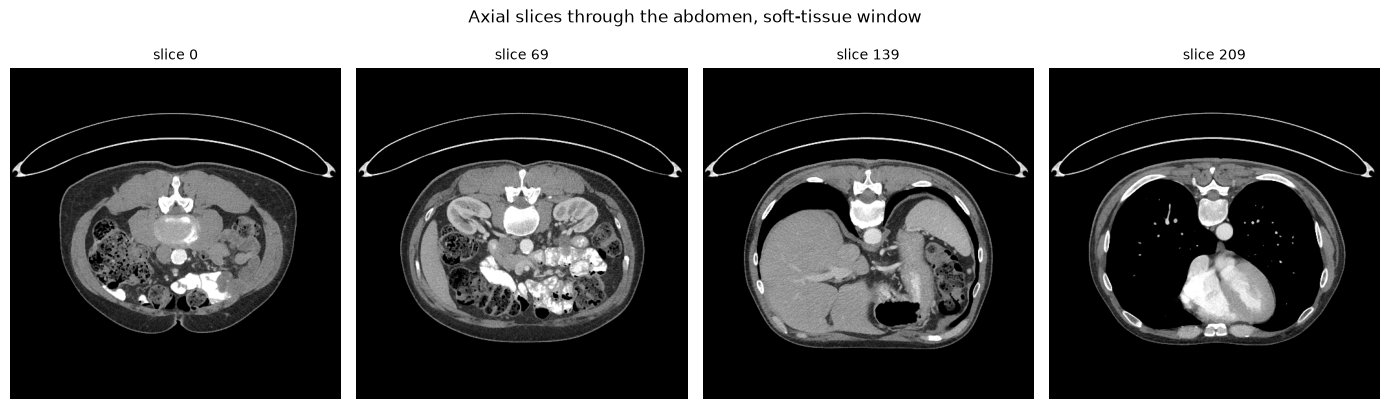

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, idx in zip(axes, np.linspace(0, n0 - 1, 4).astype(int)):
    ax.imshow(vol[idx], cmap="gray", vmin=-160, vmax=240)
    ax.set_title(f"slice {idx}", fontsize=10)
    ax.axis("off")
fig.suptitle("Axial slices through the abdomen, soft-tissue window", y=1.02)
plt.tight_layout()
plt.show()

### The other two planes

Slicing along the first axis gives the **axial** view. Slice along the second or third axis instead
and you get the **coronal** and **sagittal** views — the same data seen from the front and the side.

These views are the reason spacing matters for display too. Whenever the slice spacing differs from
the in-plane spacing, the image comes out stretched or squashed unless you pass the true pixel
proportions via `aspect`.

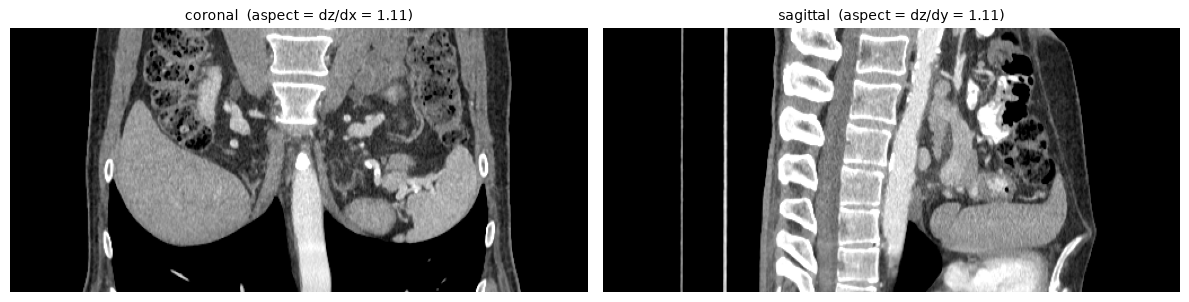

In [13]:
coronal = vol[:, n1 // 2, :]
sagittal = vol[:, :, n2 // 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(coronal, cmap="gray", vmin=-160, vmax=240, aspect=dz / dx)
axes[0].set_title(f"coronal  (aspect = dz/dx = {dz / dx:.2f})", fontsize=10)
axes[1].imshow(sagittal, cmap="gray", vmin=-160, vmax=240, aspect=dz / dy)
axes[1].set_title(f"sagittal  (aspect = dz/dy = {dz / dy:.2f})", fontsize=10)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

The coronal view is how Chapter 5 finds the L3 vertebral level: scroll down the spine until you
reach the third lumbar vertebra, then measure on that axial slice.

## Exercises

1. Call `md.fetch_pancreas_ct(1)` to get a second subject. Compare its spacing and field of view
   with the first. Would a measurement in *pixels* be comparable between the two? What about a
   measurement in cm²?
2. Recompute the tissue-fraction table for the topmost and bottommost slice of `vol`. Explain the
   difference in terms of what anatomy is in each.
3. `ct_to_tensor` currently returns one slice. Modify it to return a whole volume as a
   `(1, 1, D, H, W)` tensor, the layout a 3D segmentation network expects.
4. Deliberately skip the rescale: compute the "fat fraction" from `ds.pixel_array` without applying
   slope and intercept. How far off is it, and why does it fail so badly?

## References

- [pydicom documentation](https://pydicom.github.io/pydicom/stable/)
- [The Cancer Imaging Archive REST API](https://wiki.cancerimagingarchive.net/display/Public/NBIA+Search+REST+API+Guide)
- [PyTorch documentation](https://pytorch.org/docs/stable/index.html)
- Hounsfield GN. *Computed medical imaging.* Science. 1980;210(4465):22–28.
- Roth H, Farag A, Turkbey EB, Lu L, Liu J, Summers RM (2016).
  *Data From Pancreas-CT.* The Cancer Imaging Archive.
  [doi:10.7937/K9/TCIA.2016.tNB1kqBU](https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU)